In [1]:
import sys
for path in ['/sf/bd/packages/PassiveWFMeasurement', '/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction', '/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/']:
    if path not in sys.path:
        sys.path.append(path)

In [2]:
import torch
import h5py
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from ps_reconstruction.core.image_processing import crop_images_to_bright_spot_centers
from ps_reconstruction.core.dataloader import beam_collate_fn, BeamImageDataset, create_beam_dataloader, split_dataset
from ps_reconstruction.utils.visualization import align_images_cross_correlation_cuda, fit_gaussian_to_projection
from ps_reconstruction.core.simulation import ScreenImageGenerator

In [3]:
dfile = '/sf/data/measurements/2025/06/30/20250630_193506_EmittanceTool.h5'
# dfile = '/sf/data/measurements/2025/05/22/20250522_212838_EmittanceTool.h5'
with h5py.File(dfile, 'r') as f:
    quad_k = f['/Input/QuadK'][()]  # shape: (n_phases,)
    p0c = f['/Input/energy_eV'][()]
    fr11 = torch.tensor(f['/Input/R11'][()])
    fr12 = torch.tensor(f['/Input/R12'][()])
    fr33 = torch.tensor(f['/Input/R33'][()])
    fr34 = torch.tensor(f['/Input/R34'][()])
    images = f['/Raw_data/image'][()]  # shape: (n_phases, n_images, y, x)
    x_axis = f['/Raw_data/x_axis'][0,0].astype(float)/1e3  # shape: (x,)
    y_axis = f['/Raw_data/y_axis'][0,0].astype(float)/1e3  # shape: (y,)
    screen_res = f['/Input/screen_resolution'][()]  # e.g., (100, 100)

In [4]:
gt_beam = torch.load(
    "./logs/beam_training/version_62/final_results/reconstructed_beam.pt", weights_only=False
)

In [5]:
lattice = ScreenImageGenerator(fr11, fr12, fr33, fr34, quad_k[-1], 160, 160, 7.7e-6, 7.8e-6, device= 'cuda')

Using device: cuda


/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/core/simulation.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.r11 = torch.tensor(r11, dtype=torch.float32, device=self.device)
/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/core/simulation.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.r12 = torch.tensor(r12, dtype=torch.float32, device=self.device)
/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/core/simulation.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.r33 = tor

In [6]:
# generated_images = lattice.generate_screen_image_with_params(gt_beam, fr11, fr12, fr33, fr34, quad_k=quad_k[-1], use_kde=True, gaussian_blur_sigma=2)
generated_images = lattice.generate_screen_image(gt_beam, gaussian_blur_sigma=3)

OutOfMemoryError: CUDA out of memory. Tried to allocate 196.00 MiB. GPU 0 has a total capacity of 4.92 GiB of which 33.75 MiB is free. Including non-PyTorch memory, this process has 670.00 MiB memory in use. Of the allocated memory 594.03 MiB is allocated by PyTorch, and 15.97 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

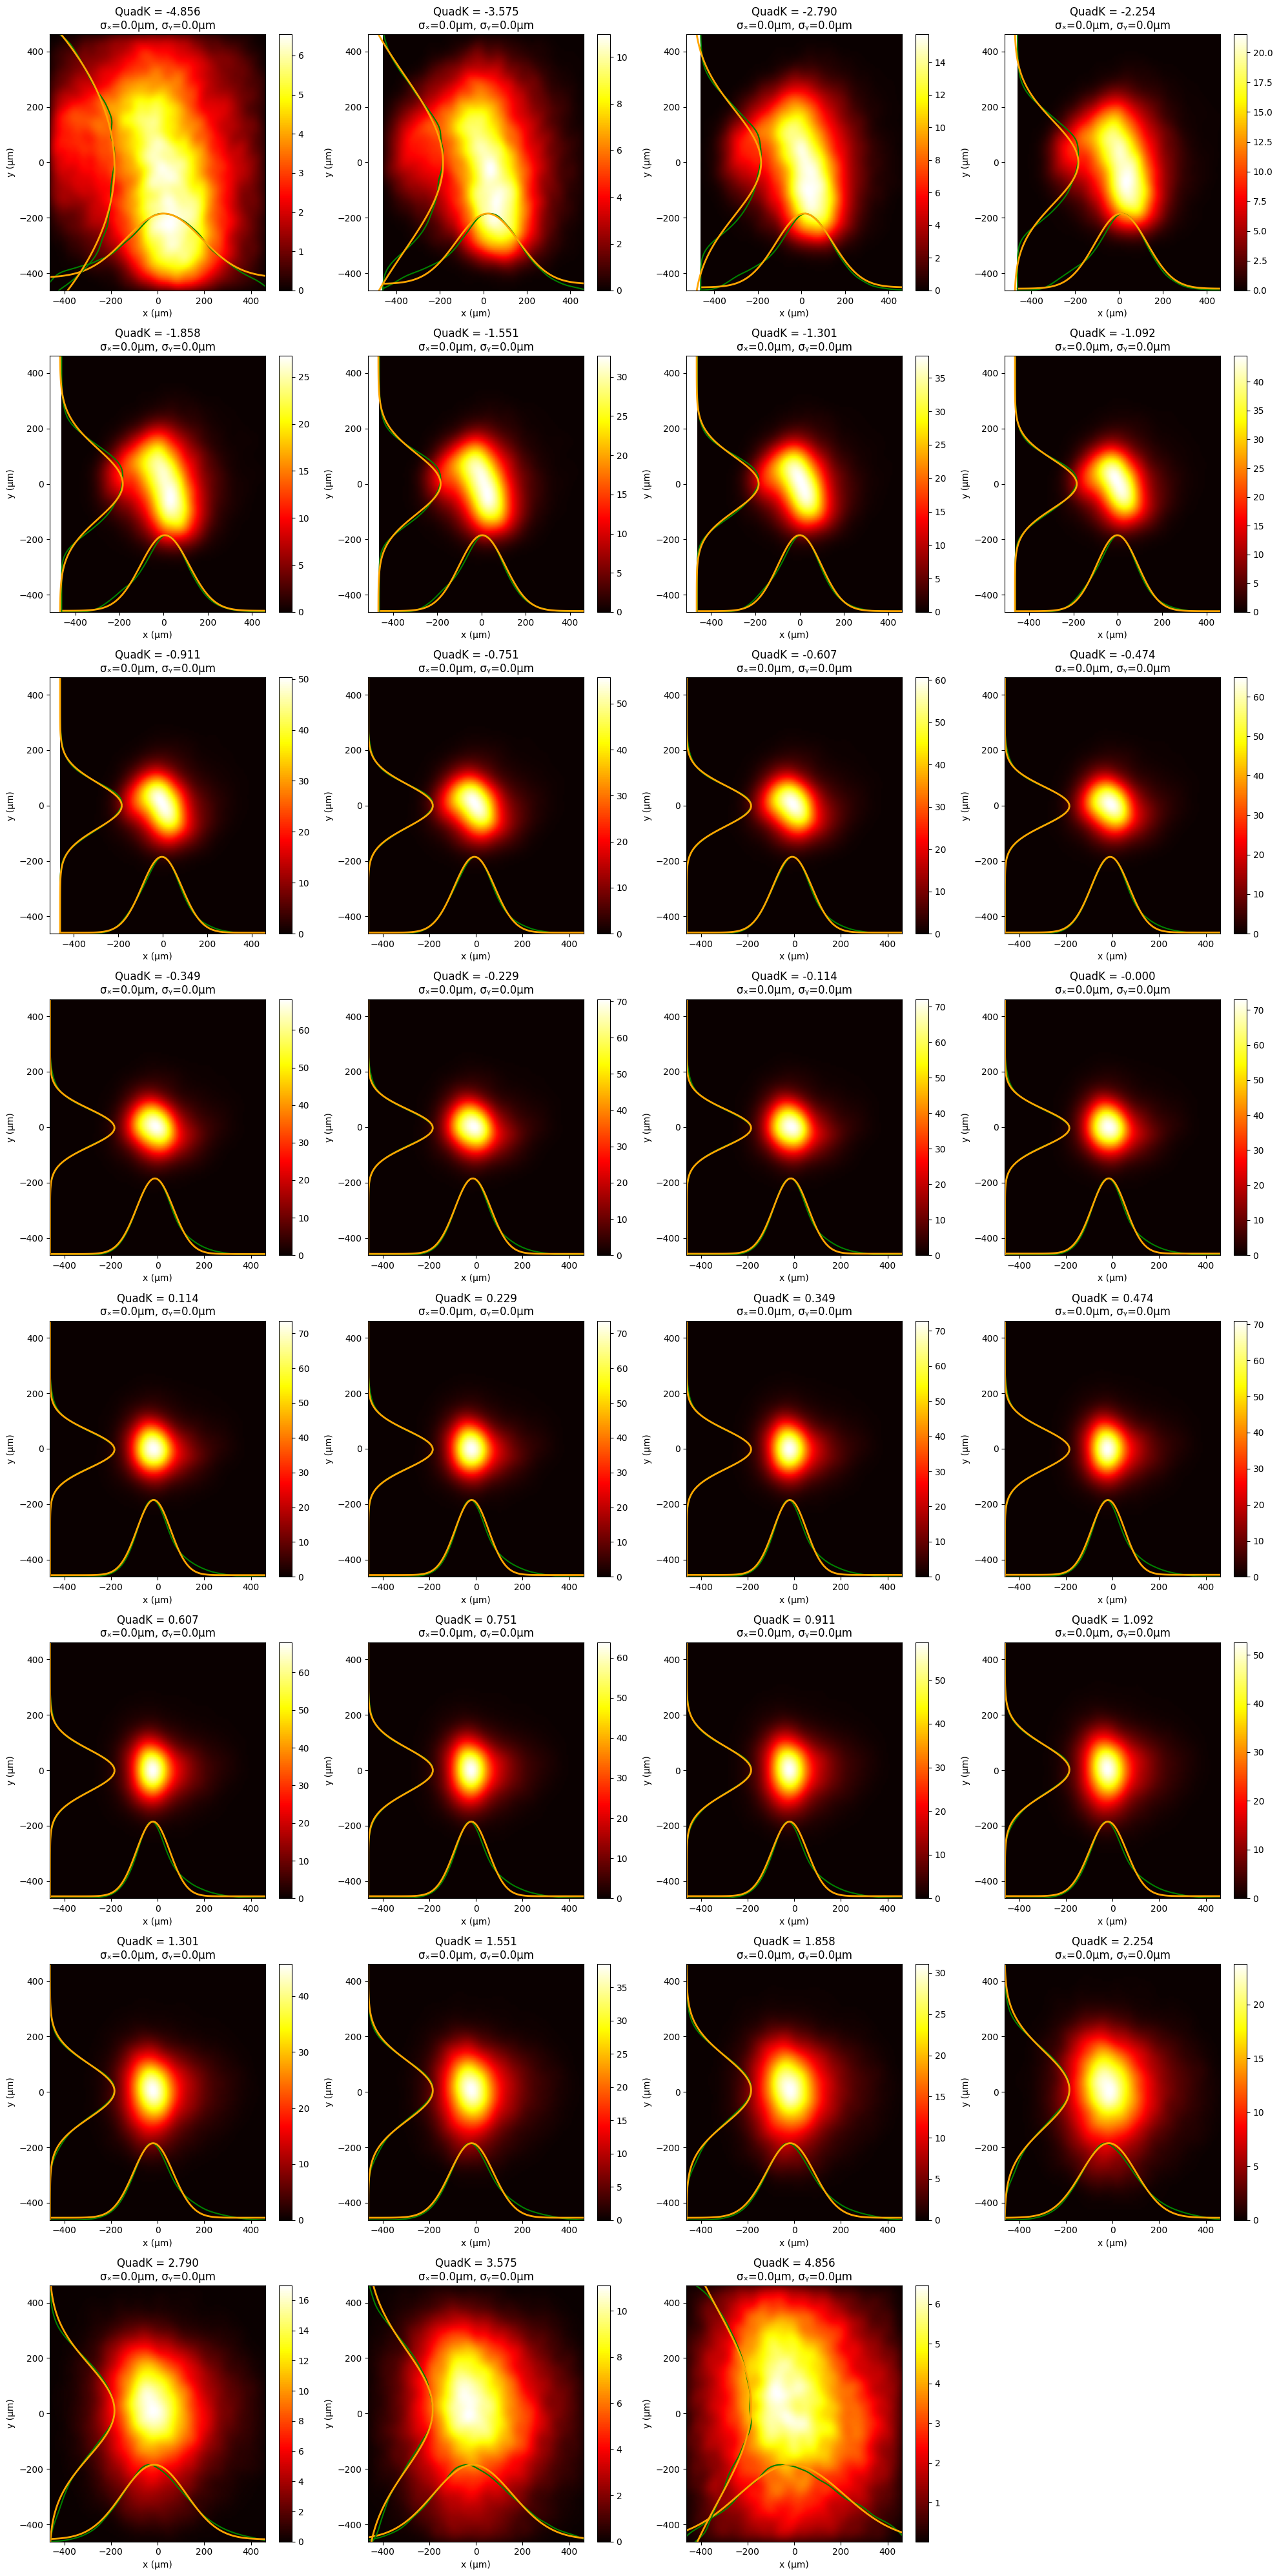

[{'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f25a178f440>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f25e00af2f0>,
  'sigma_x': np.float64(0.0001633086952469204),
  'sigma_y': np.float64(0.027367934341665002),
  'imshow_outp': <matplotlib.image.AxesImage at 0x7f25e3d365d0>,
  'plot_gauss_y_outp': [<matplotlib.lines.Line2D at 0x7f25a156c320>],
  'plot_proj_y_outp': [<matplotlib.lines.Line2D at 0x7f25a1737d70>],
  'plot_gauss_x_outp': [<matplotlib.lines.Line2D at 0x7f25a17379b0>],
  'plot_proj_x_outp': [<matplotlib.lines.Line2D at 0x7f25e3e88fe0>],
  'extent': [np.float32(-462.0),
   np.float32(462.0),
   np.float32(-462.0),
   np.float32(462.0)]},
 {'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f25a1597440>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f25a15974d0>,
  'sigma_x': np.floa

In [ ]:
from ps_reconstruction.utils.visualization import prepare_images_for_plotting, plot_images_with_proj

images_for_plotting = prepare_images_for_plotting(generated_images, quad_k[-1], lattice)

plot_images_with_proj(images_for_plotting, x_pixel_size=7.7e-6, y_pixel_size=7.8e-6)

In [6]:
# Load the HDF5 file
dfile = '/sf/data/measurements/2025/06/30/20250630_193506_EmittanceTool.h5'
# dfile = '/sf/data/measurements/2025/05/22/20250522_212838_EmittanceTool.h5'
with h5py.File(dfile, 'r') as f:
    # Store original data (before slicing) for ScreenImageGenerator __init__
    original_r11 = f['/Input/R11'][()]
    original_r12 = f['/Input/R12'][()]
    original_r33 = f['/Input/R33'][()]
    original_r34 = f['/Input/R34'][()]
    original_quad_k = f['/Input/QuadK'][()][-1] # shape: (n_phases,)
    p0c = f['/Input/energy_eV'][()]
    images = f['/Raw_data/image'][()]  # shape: (n_phases, n_images, y, x)
    x_axis = f['/Raw_data/x_axis'][0,0].astype(float)/1e6  # shape: (x,)
    y_axis = f['/Raw_data/y_axis'][0,0].astype(float)/1e6  # shape: (y,)
    screen_res = f['/Input/screen_resolution'][()] # e.g., (100, 100)

In [7]:
# Apply background subtraction
proc_images = np.array(images, dtype=np.float64) - 1000
proc_images[proc_images < 0 ] = 0

# Select specific indices to use
# This selects the images and corresponding R-matrix values.
# Ensure 'to_use_indices' aligns with the dimensions of original_rXX and proc_images
# to_use_indices = [3,4,5,6,7,9,13,14,15,16]
# to_use_indices.extend(list(int(i) for i in np.arange(20,30,1)))
to_use_indices = np.arange(0,31,1)

# Crop images to bright spot centers (apply to the first image of each phase for now)
processed_images_array, processed_x_axis, processed_y_axis = crop_images_to_bright_spot_centers(
    proc_images[:, 0], # Assuming you always use the first image from n_images dimension
    target_x=160, 
    target_y=160, 
    x_axis=x_axis, 
    y_axis=y_axis
)

# Filter all data by to_use_indices
filtered_r11 = original_r11[to_use_indices]
filtered_r12 = original_r12[to_use_indices]
filtered_r33 = original_r33[to_use_indices]
filtered_r34 = original_r34[to_use_indices]
filtered_quad_k = original_quad_k[to_use_indices]

processed_tensors = torch.tensor(processed_images_array[to_use_indices], dtype=torch.float32)

# Ensure R-matrix and quad_k are 1D arrays of values for direct mapping to each sample
# (The DataLoader will stack them later)
quad_torch_k_for_dataset = torch.tensor(filtered_quad_k, dtype=torch.float32).flatten() # Ensure 1D

# Calculate pixel sizes for the cropped images
x_pixel_size = abs(processed_x_axis[0][1] - processed_x_axis[0][0])
y_pixel_size = abs(processed_y_axis[0][1] - processed_y_axis[0][0])
x_pixel_size_tensor = torch.tensor(x_pixel_size, dtype=torch.float32)
y_pixel_size_tensor = torch.tensor(y_pixel_size, dtype=torch.float32)

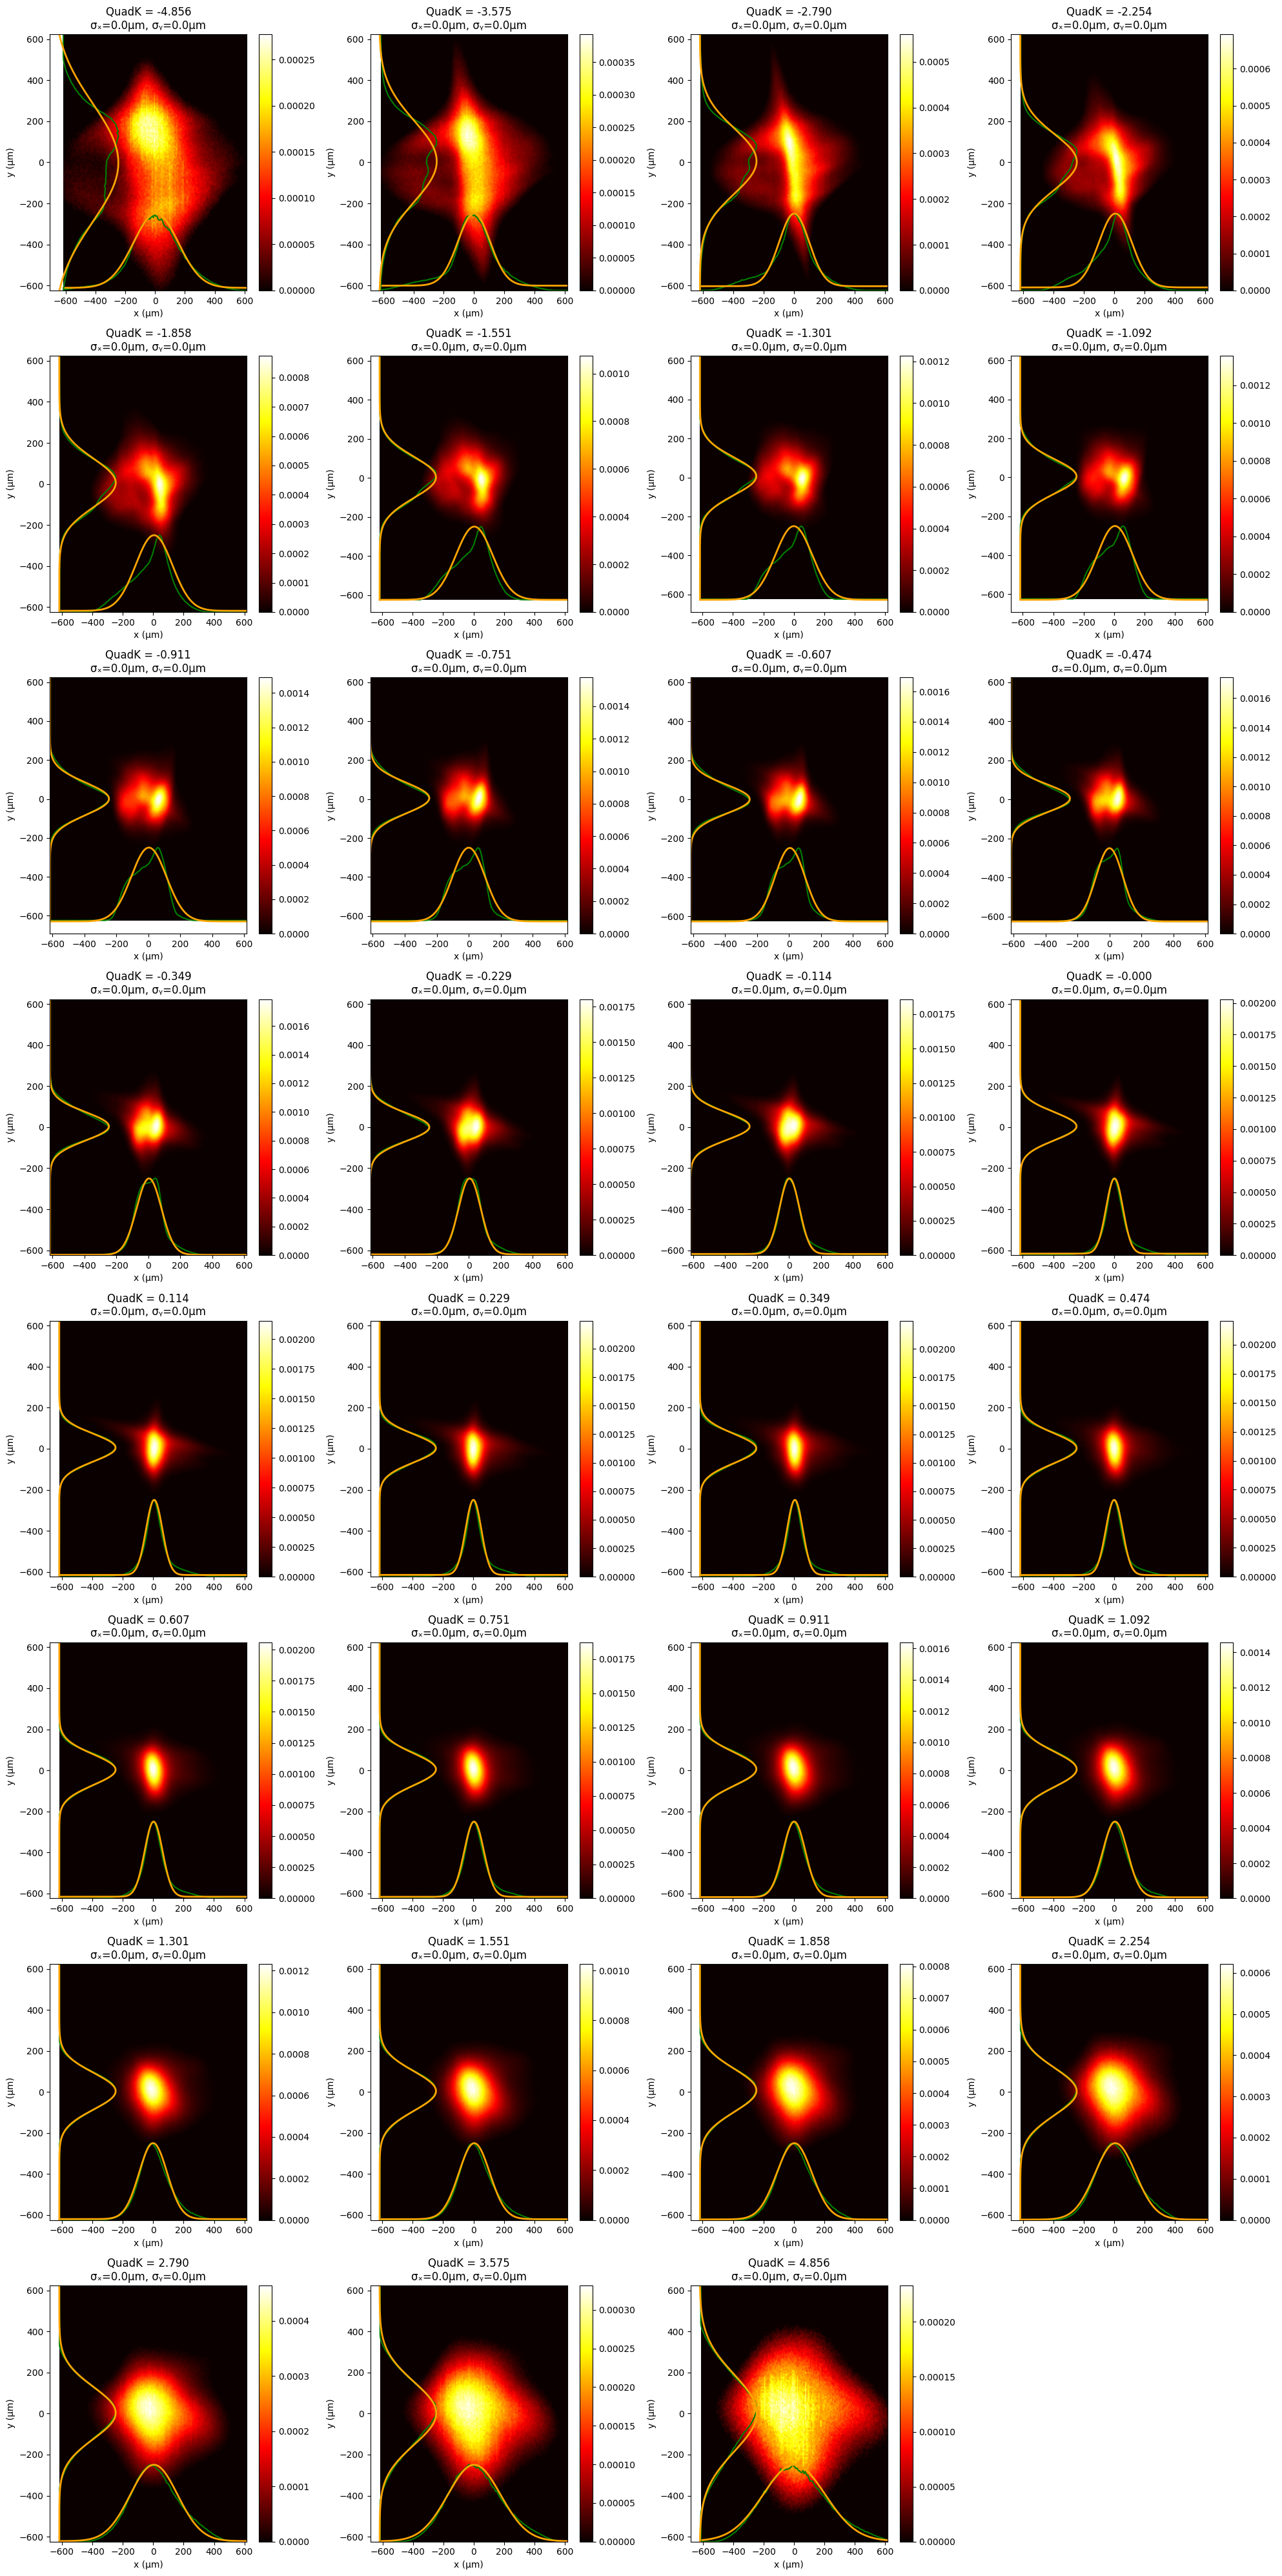

[{'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f67e01447a0>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f6971e0cd70>,
  'sigma_x': np.float64(0.0001513115379761965),
  'sigma_y': np.float64(0.0002894677542085588),
  'imshow_outp': <matplotlib.image.AxesImage at 0x7f67ea2badb0>,
  'plot_gauss_y_outp': [<matplotlib.lines.Line2D at 0x7f67e0144590>],
  'plot_proj_y_outp': [<matplotlib.lines.Line2D at 0x7f67e02e8c20>],
  'plot_gauss_x_outp': [<matplotlib.lines.Line2D at 0x7f67e01443b0>],
  'plot_proj_x_outp': [<matplotlib.lines.Line2D at 0x7f67e06bcaa0>],
  'extent': [np.float32(-616.0),
   np.float32(616.0),
   np.float32(-624.0),
   np.float32(624.0)]},
 {'gf_x': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f67e016ac30>,
  'gf_y': <ps_reconstruction.utils.visualization.plot_images_with_proj.<locals>.FitResult at 0x7f67e016ade0>,
  'sigma_x': np.flo

In [8]:
from ps_reconstruction.utils.visualization import prepare_images_for_plotting, plot_images_with_proj

images_for_plotting = prepare_images_for_plotting(processed_tensors, quad_k[-1], lattice)

plot_images_with_proj(images_for_plotting, x_pixel_size=7.7e-4, y_pixel_size=7.8e-4)

In [9]:
# Prepare data list for BeamImageDataset
# Each item in `data_list_for_dataset` represents ONE sample with its image and R-matrix parameters.
data_list_for_dataset = []
for i in range(len(to_use_indices)): # Iterate through the already-filtered data
    data_list_for_dataset.append({
        'image': processed_tensors[i], # This is a single 2D image tensor for this sample
        'r11': [filtered_r11[i]],       # A single r11 value for this sample
        'r12': [filtered_r12[i]],
        'r33': [filtered_r33[i]],
        'r34': [filtered_r34[i]],
        'quad_k': quad_torch_k_for_dataset[i] # A single quad_k value for this sample
    })

# Create the full dataset from the prepared list
full_filtered_dataset = BeamImageDataset(data_list_for_dataset)
print(f"Total samples in filtered dataset: {len(full_filtered_dataset)}")

all_filtered_indices = list(range(len(full_filtered_dataset)))
train_indices = [i for i in all_filtered_indices if i % 2 == 0]
test_indices = [i for i in all_filtered_indices if i % 2 != 0]
# train_indices = [0,1,2,3,4,6,8,10,12,14,16,17,18,19]
# test_indices = [5,7,9,11,13,15]

print(f"Train indices: {train_indices}")
print(f"Test indices: {test_indices}")

# Split the dataset
train_ds, test_ds = split_dataset(full_filtered_dataset, train_indices)

print(f"Train dataset size: {len(train_ds)}")
print(f"Test dataset size: {len(test_ds)}")

Total samples in filtered dataset: 31
Train indices: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
Test indices: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29]
Train dataset size: 16
Test dataset size: 15


/afs/psi.ch/intranet/SF/Beamdynamics/Harsh/ps_reconstruction/core/dataloader.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  quad_k = torch.tensor(item['quad_k'], dtype=torch.float32)


In [8]:
print(filtered_r11[test_indices])
print(test_ds[0])

[ 2.41699617  1.99014088  1.57049089  1.0862445   0.91382856  0.43269067
  0.1765395  -0.16754194 -0.69241546 -1.67137831]
{'image': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]), 'r11': tensor([2.4170]), 'r12': tensor([5.2289]), 'r33': tensor([-0.3975]), 'r34': tensor([5.0188]), 'quad_k': tensor(-1.8583), 'x_axis': None, 'y_axis': None}


In [10]:
lattice = ScreenImageGenerator(filtered_r11[test_indices], filtered_r12[test_indices], filtered_r33[test_indices], filtered_r34[test_indices], quad_k[-1][test_indices], 160, 160, 7.7e-6, 7.8e-6, device= 'cuda')
generated_images = lattice.generate_screen_image(gt_beam, gaussian_blur_sigma=3)

Using device: cuda


In [11]:
print("\nCalculating Emittance from Reconstructed Beam:")

x_coords = gt_beam.x.clone().detach()
px_coords = gt_beam.px.clone().detach()
y_coords = gt_beam.y.clone().detach()
py_coords = gt_beam.py.clone().detach()

x_squared = torch.mean(x_coords**2)
px_squared = torch.mean(px_coords**2)
x_px_cross = torch.mean(x_coords * px_coords)

y_squared = torch.mean(y_coords**2)
py_squared = torch.mean(py_coords**2)
y_py_cross = torch.mean(y_coords * py_coords)

print(f"<x^2> = {x_squared.item():.4e}")
print(f"<px^2> = {px_squared.item():.4e}")
print(f"<xpx> = {x_px_cross.item():.4e}")
print(f"<y^2> = {y_squared.item():.4e}")
print(f"<py^2> = {py_squared.item():.4e}")
print(f"<ypy> = {y_py_cross.item():.4e}")

# Emittance calculation
emittance_x = torch.sqrt(torch.abs(x_squared * px_squared - x_px_cross**2)) # Use abs for numerical stability
alpha_x = -x_px_cross / emittance_x
beta_x = x_squared / emittance_x
gamma_x = px_squared / emittance_x # Add gamma_x for completeness

print(f'\nReconstructed Emittance x: {emittance_x.item():.4e} m.rad')
print(f'Reconstructed Alpha x: {alpha_x.item():.4f}')
print(f'Reconstructed Beta x: {beta_x.item():.4f} m')
# print(f'Reconstructed Gamma x: {gamma_x.item():.4f} rad/m')

emittance_y = torch.sqrt(torch.abs(y_squared * py_squared - y_py_cross**2)) # Use abs for numerical stability
alpha_y = -y_py_cross / emittance_y
beta_y = y_squared / emittance_y
gamma_y = py_squared / emittance_y # Add gamma_y for completeness

print(f'\nReconstructed Emittance y: {emittance_y.item():.4e} m.rad')
print(f'Reconstructed Alpha y: {alpha_y.item():.4f}')
print(f'Reconstructed Beta y: {beta_y.item():.4f} m')
# print(f'Reconstructed Gamma y: {gamma_y.item():.4f} rad/m')


print("\nOriginal (Target) Values for Comparison:")

print(f'Target Emittance x: {torch.tensor(6.645688285621224e-10).item():.4e} m.rad')
print(f'Target Alpha x: {torch.tensor(0.9628247831366624).item():.4f}')
print(f'Target Beta x: {torch.tensor(5.349556897208785).item():.4f} m')

print(f'\nTarget Emittance y: {torch.tensor(8.907483248638635e-10).item():.4e} m.rad')
print(f'Target Alpha y: {torch.tensor(1.1845382840223906).item():.4f}')
print(f'Target Beta y: {torch.tensor(6.047631945676178).item():.4f} m')

emittance_results = {
    'emittance_x': emittance_x.item(),
    'alpha_x': alpha_x.item(),
    'beta_x': beta_x.item(),
    'emittance_y': emittance_y.item(),
    'alpha_y': alpha_y.item(),
    'beta_y': beta_y.item(),
    'target_emittance_x': torch.tensor(6.645688285621224e-10).item(),
    'target_emittance_y': torch.tensor(8.907483248638635e-10).item(),
    'target_alpha_x': torch.tensor(0.9628247831366624).item(),
    'target_alpha_y': torch.tensor(1.1845382840223906).item(),
    'target_beta_x': torch.tensor(5.349556897208785).item(),
    'target_beta_y': torch.tensor(6.047631945676178).item()
}


Calculating Emittance from Reconstructed Beam:
<x^2> = 5.8014e-09
<px^2> = 4.3421e-10
<xpx> = -9.7470e-10
<y^2> = 2.6939e-09
<py^2> = 3.1439e-10
<ypy> = -5.5460e-10

Reconstructed Emittance x: 1.2526e-09 m.rad
Reconstructed Alpha x: 0.7781
Reconstructed Beta x: 4.6315 m

Reconstructed Emittance y: 7.3441e-10 m.rad
Reconstructed Alpha y: 0.7552
Reconstructed Beta y: 3.6681 m

Original (Target) Values for Comparison:
Target Emittance x: 6.6457e-10 m.rad
Target Alpha x: 0.9628
Target Beta x: 5.3496 m

Target Emittance y: 8.9075e-10 m.rad
Target Alpha y: 1.1845
Target Beta y: 6.0476 m


In [12]:
from ps_reconstruction.core.results import save_results_to_logs

device = 'cuda'

test_dataloader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False, collate_fn=beam_collate_fn)
version = 'spare_62'
test_batch = next(iter(test_dataloader))

# Move test batch data to device
target_images_test = test_batch['images'].to(device)
r11_test = test_batch['r11'].to(device)
r12_test = test_batch['r12'].to(device)
r33_test = test_batch['r33'].to(device)
r34_test = test_batch['r34'].to(device)
quad_k_test = test_batch['quad_k'].to(device) # Quad K for plotting

save_results_to_logs(reconstructed_beam=gt_beam, 
                     target_images_test=target_images_test, 
                     predicted_images_test= generated_images, 
                     quad_k_test=quad_k_test,
                     emittance_results=emittance_results,
                     logger_log_dir=f'./logs/beam_training/version_{version}')

Saving results to: ./logs/beam_training/version_spare_62/final_results
✓ Saved reconstructed beam to: ./logs/beam_training/version_spare_62/final_results/reconstructed_beam.pt
✓ Saved beam distribution plot to: ./logs/beam_training/version_spare_62/final_results/reconstructed_beam_distribution.png
✓ Saved emittance results to: ./logs/beam_training/version_spare_62/final_results/emittance_results.txt
Creating sigma comparison plots and CSV...
✓ Saved sigma comparison plot to: ./logs/beam_training/version_spare_62/final_results/sigma_comparison.png
✓ Saved sigma values to CSV: ./logs/beam_training/version_spare_62/final_results/sigma_values.csv
Creating concatenated comparison images with proper axes...
✓ Saved comparison images to: ./logs/beam_training/version_spare_62/final_results/test_images_comparison.png


'./logs/beam_training/version_spare_62/final_results'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
# 1. Full dataset
full_dataloader = DataLoader(full_filtered_dataset, batch_size=len(full_filtered_dataset), shuffle=False, collate_fn=beam_collate_fn)
full_batch = next(iter(full_dataloader))
original_images = full_batch['images']
quad_k = full_batch['quad_k'].numpy()  # Extract quad_k values
lattice = ScreenImageGenerator(filtered_r11, filtered_r12, filtered_r33, filtered_r34, filtered_quad_k, 120, 120, x_pixel_size, y_pixel_size, device= 'cuda')
predicted_images = lattice.generate_screen_image(gt_beam, gaussian_blur_sigma=3)

Using device: cuda


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import torch

def calculate_total_intensity(image):
    """Calculate total intensity by summing all pixel values."""
    return np.sum(image)

def calculate_gaussian_fitted_intensity(image, axis=None):
    """
    Calculate intensity under Gaussian fit.
    If axis is None, fit 2D Gaussian. Otherwise fit 1D Gaussian to projection.
    """
    if axis is None:
        # 2D Gaussian fitting - more complex, let's use projection method
        # Get both projections and multiply their integrals
        proj_x = np.sum(image, axis=0)  # Sum along y-axis
        proj_y = np.sum(image, axis=1)  # Sum along x-axis
        
        # Fit Gaussians to both projections
        sigma_x = fit_gaussian_to_projection(image, axis=0)
        sigma_y = fit_gaussian_to_projection(image, axis=1)
        
        if sigma_x is None or sigma_y is None:
            return None
            
        # Calculate Gaussian integral approximation
        # For 2D Gaussian: integral = 2π * A * σx * σy
        # We'll estimate A from the peak intensity
        peak_intensity = np.max(image)
        gaussian_integral = 2 * np.pi * peak_intensity * sigma_x * sigma_y
        
        return gaussian_integral
    else:
        # 1D projection method
        projection = np.sum(image, axis=axis)
        x_proj = np.arange(len(projection))
        
        if np.max(projection) == 0:
            return None
            
        # Fit Gaussian
        try:
            amplitude_guess = np.max(projection)
            mean_guess = np.average(x_proj, weights=projection)
            sigma_guess = np.sqrt(np.average((x_proj - mean_guess)**2, weights=projection))
            
            def gaussian_1d(x, amplitude, mean, sigma):
                return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))
            
            popt, _ = curve_fit(gaussian_1d, x_proj, projection, 
                               p0=[amplitude_guess, mean_guess, sigma_guess],
                               maxfev=1000)
            
            # Calculate integral of fitted Gaussian: sqrt(2π) * A * σ
            gaussian_integral = np.sqrt(2 * np.pi) * popt[0] * abs(popt[2])
            return gaussian_integral
            
        except:
            return None

def gaussian(x, amplitude, mean, sigma):
    """Gaussian function for fitting."""
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

def fit_gaussian_to_projection(image, axis=0):
    """
    Fit Gaussian to image projection and return sigma value.
    (This function already exists in your code, including it for completeness)
    """
    projection = np.sum(image, axis=axis)
    x_proj = np.arange(len(projection))
    
    if np.max(projection) == 0:
        return None
    
    amplitude_guess = np.max(projection)
    mean_guess = np.average(x_proj, weights=projection)
    sigma_guess = np.sqrt(np.average((x_proj - mean_guess)**2, weights=projection))
    
    try:
        popt, _ = curve_fit(gaussian, x_proj, projection, 
                           p0=[amplitude_guess, mean_guess, sigma_guess],
                           maxfev=1000)
        return abs(popt[2])  # Return sigma (absolute value)
    except:
        return None

print("Intensity calculation functions defined successfully!")

Intensity calculation functions defined successfully!


In [11]:
def analyze_image_intensities(original_images, predicted_images):
    """
    Analyze intensities for original and predicted images.
    Handles the case where:
    - original_images: tensor of shape (N, H, W) 
    - predicted_images: list of N tensors each of shape (H, W)
    """
    # Convert original images (tensor) to numpy
    if torch.is_tensor(original_images):
        original_np = original_images.cpu().numpy()
    else:
        original_np = np.array(original_images)
    
    # Convert predicted images (list of tensors) to numpy array
    if isinstance(predicted_images, list):
        # Convert each tensor in the list to numpy and stack them
        predicted_list = []
        for img in predicted_images:
            if torch.is_tensor(img):
                predicted_list.append(img.detach().cpu().numpy())
            else:
                predicted_list.append(np.array(img))
        predicted_np = np.stack(predicted_list, axis=0)
    else:
        # If it's already a tensor or array
        if torch.is_tensor(predicted_images):
            predicted_np = predicted_images.detach().cpu().numpy()
        else:
            predicted_np = np.array(predicted_images)
    
    print(f"Original images shape: {original_np.shape}, type: {type(original_np)}")
    print(f"Predicted images shape: {predicted_np.shape}, type: {type(predicted_np)}")
    
    # Ensure both have the same number of images
    n_images = min(original_np.shape[0], predicted_np.shape[0])
    print(f"Analyzing {n_images} image pairs...")
    
    results = {
        'original': {
            'total_intensity': [],
            'gaussian_fitted_intensity_x': [],
            'gaussian_fitted_intensity_y': [],
            'gaussian_fitted_intensity_2d': []
        },
        'predicted': {
            'total_intensity': [],
            'gaussian_fitted_intensity_x': [],
            'gaussian_fitted_intensity_y': [],
            'gaussian_fitted_intensity_2d': []
        },
        'ratios': {
            'total_intensity_ratio': [],
            'gaussian_x_ratio': [],
            'gaussian_y_ratio': [],
            'gaussian_2d_ratio': []
        }
    }
    
    for i in range(n_images):
        orig_img = original_np[i]
        pred_img = predicted_np[i]
        
        # Ensure both are numpy arrays
        if not isinstance(orig_img, np.ndarray):
            orig_img = np.array(orig_img)
        if not isinstance(pred_img, np.ndarray):
            pred_img = np.array(pred_img)
        
        # For now, skip alignment to avoid CUDA issues - you can add it back later
        aligned_orig_img = orig_img
        
        # Calculate total intensities
        orig_total = calculate_total_intensity(aligned_orig_img)
        pred_total = calculate_total_intensity(pred_img)
        
        results['original']['total_intensity'].append(orig_total)
        results['predicted']['total_intensity'].append(pred_total)
        results['ratios']['total_intensity_ratio'].append(pred_total / orig_total if orig_total > 0 else 0)
        
        # Calculate Gaussian fitted intensities (X projection)
        orig_gauss_x = calculate_gaussian_fitted_intensity(aligned_orig_img, axis=0)
        pred_gauss_x = calculate_gaussian_fitted_intensity(pred_img, axis=0)
        
        results['original']['gaussian_fitted_intensity_x'].append(orig_gauss_x)
        results['predicted']['gaussian_fitted_intensity_x'].append(pred_gauss_x)
        
        if orig_gauss_x is not None and pred_gauss_x is not None and orig_gauss_x > 0:
            results['ratios']['gaussian_x_ratio'].append(pred_gauss_x / orig_gauss_x)
        else:
            results['ratios']['gaussian_x_ratio'].append(None)
        
        # Calculate Gaussian fitted intensities (Y projection)
        orig_gauss_y = calculate_gaussian_fitted_intensity(aligned_orig_img, axis=1)
        pred_gauss_y = calculate_gaussian_fitted_intensity(pred_img, axis=1)
        
        results['original']['gaussian_fitted_intensity_y'].append(orig_gauss_y)
        results['predicted']['gaussian_fitted_intensity_y'].append(pred_gauss_y)
        
        if orig_gauss_y is not None and pred_gauss_y is not None and orig_gauss_y > 0:
            results['ratios']['gaussian_y_ratio'].append(pred_gauss_y / orig_gauss_y)
        else:
            results['ratios']['gaussian_y_ratio'].append(None)
        
        # Calculate 2D Gaussian fitted intensities
        orig_gauss_2d = calculate_gaussian_fitted_intensity(aligned_orig_img, axis=None)
        pred_gauss_2d = calculate_gaussian_fitted_intensity(pred_img, axis=None)
        
        results['original']['gaussian_fitted_intensity_2d'].append(orig_gauss_2d)
        results['predicted']['gaussian_fitted_intensity_2d'].append(pred_gauss_2d)
        
        if orig_gauss_2d is not None and pred_gauss_2d is not None and orig_gauss_2d > 0:
            results['ratios']['gaussian_2d_ratio'].append(pred_gauss_2d / orig_gauss_2d)
        else:
            results['ratios']['gaussian_2d_ratio'].append(None)
        
        if (i + 1) % 5 == 0:
            print(f"Processed {i + 1}/{n_images} images")
    
    return results

# Analyze the intensities
intensity_results = analyze_image_intensities(processed_tensors, predicted_images)
print("Intensity analysis completed!")

Original images shape: (20, 120, 120), type: <class 'numpy.ndarray'>
Predicted images shape: (20, 120, 120), type: <class 'numpy.ndarray'>
Analyzing 20 image pairs...
Processed 5/20 images
Processed 10/20 images
Processed 15/20 images
Processed 20/20 images
Intensity analysis completed!


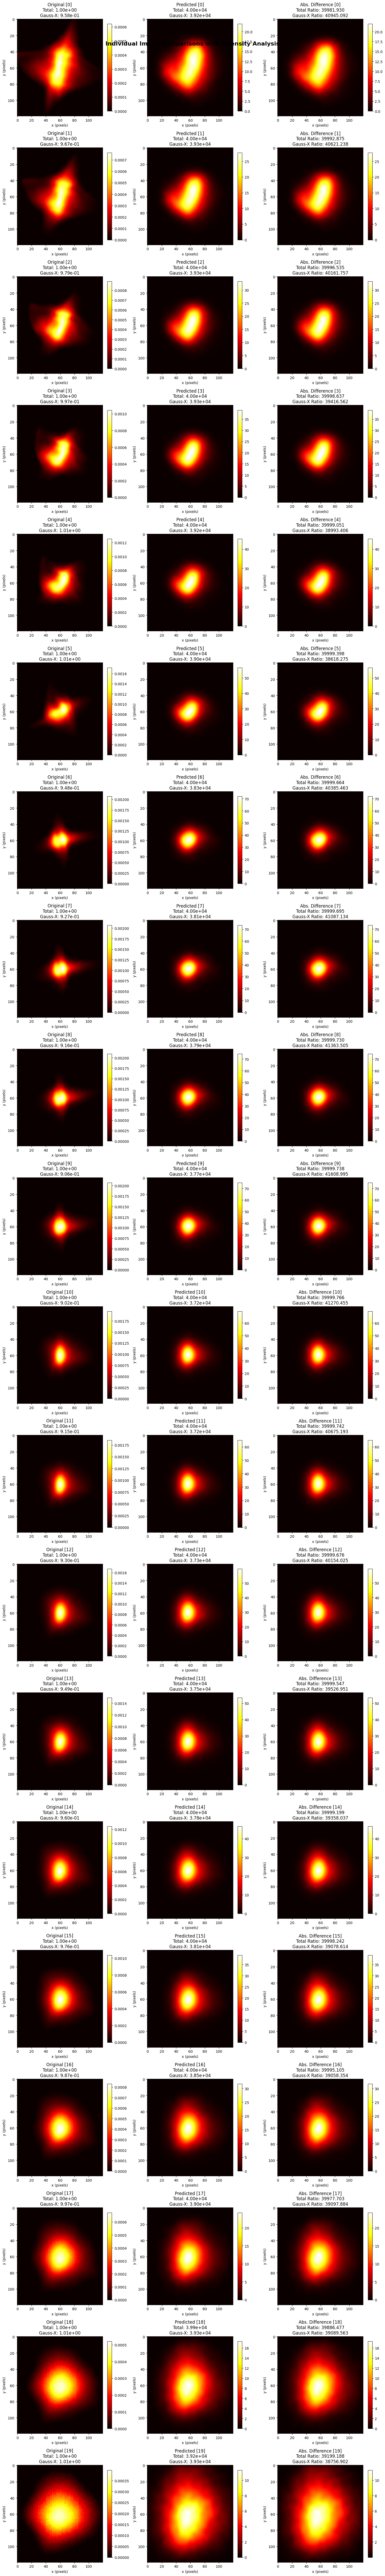

In [13]:
def plot_individual_image_comparisons(original_images, predicted_images, results, max_images=6):
    """Plot individual image comparisons with intensity information."""
    
    # Convert to numpy if needed
    if torch.is_tensor(original_images):
        original_np = original_images.cpu().numpy()
    else:
        original_np = np.array(original_images)
    
    if isinstance(predicted_images, list):
        predicted_list = []
        for img in predicted_images:
            if torch.is_tensor(img):
                predicted_list.append(img.detach().cpu().numpy())
            else:
                predicted_list.append(np.array(img))
        predicted_np = np.stack(predicted_list, axis=0)
    else:
        if torch.is_tensor(predicted_images):
            predicted_np = predicted_images.detach().cpu().numpy()
        else:
            predicted_np = np.array(predicted_images)
    
    n_images = min(original_np.shape[0], predicted_np.shape[0], max_images)
    
    fig, axes = plt.subplots(n_images, 3, figsize=(15, 5*n_images))
    if n_images == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Individual Image Comparisons with Intensity Analysis', fontsize=16, fontweight='bold')
    
    for i in range(n_images):
        orig_img = original_np[i]
        pred_img = predicted_np[i]
        diff_img = np.abs(orig_img - pred_img)
        
        # Get intensity values for this image
        orig_total = results['original']['total_intensity'][i]
        pred_total = results['predicted']['total_intensity'][i]
        total_ratio = results['ratios']['total_intensity_ratio'][i]
        
        orig_gauss_x = results['original']['gaussian_fitted_intensity_x'][i]
        pred_gauss_x = results['predicted']['gaussian_fitted_intensity_x'][i]
        gauss_x_ratio = results['ratios']['gaussian_x_ratio'][i]
        
        # Plot original image
        im1 = axes[i, 0].imshow(orig_img, cmap='hot', aspect='auto')
        axes[i, 0].set_title(f'Original [{i}]\nTotal: {orig_total:.2e}\nGauss-X: {orig_gauss_x:.2e}' if orig_gauss_x else f'Original [{i}]\nTotal: {orig_total:.2e}')
        plt.colorbar(im1, ax=axes[i, 0], fraction=0.046)
        
        # Plot predicted image
        im2 = axes[i, 1].imshow(pred_img, cmap='hot', aspect='auto')
        axes[i, 1].set_title(f'Predicted [{i}]\nTotal: {pred_total:.2e}\nGauss-X: {pred_gauss_x:.2e}' if pred_gauss_x else f'Predicted [{i}]\nTotal: {pred_total:.2e}')
        plt.colorbar(im2, ax=axes[i, 1], fraction=0.046)
        
        # Plot difference
        im3 = axes[i, 2].imshow(diff_img, cmap='hot', aspect='auto')
        axes[i, 2].set_title(f'Abs. Difference [{i}]\nTotal Ratio: {total_ratio:.3f}\nGauss-X Ratio: {gauss_x_ratio:.3f}' if gauss_x_ratio else f'Abs. Difference [{i}]\nTotal Ratio: {total_ratio:.3f}')
        plt.colorbar(im3, ax=axes[i, 2], fraction=0.046)
        
        # Set labels
        for j in range(3):
            axes[i, j].set_xlabel('x (pixels)')
            axes[i, j].set_ylabel('y (pixels)')
    
    plt.tight_layout()
    plt.show()

plot_individual_image_comparisons(processed_tensors, predicted_images, intensity_results, max_images=20)

## Parse emittance data and create emittane, alpha and beta plot

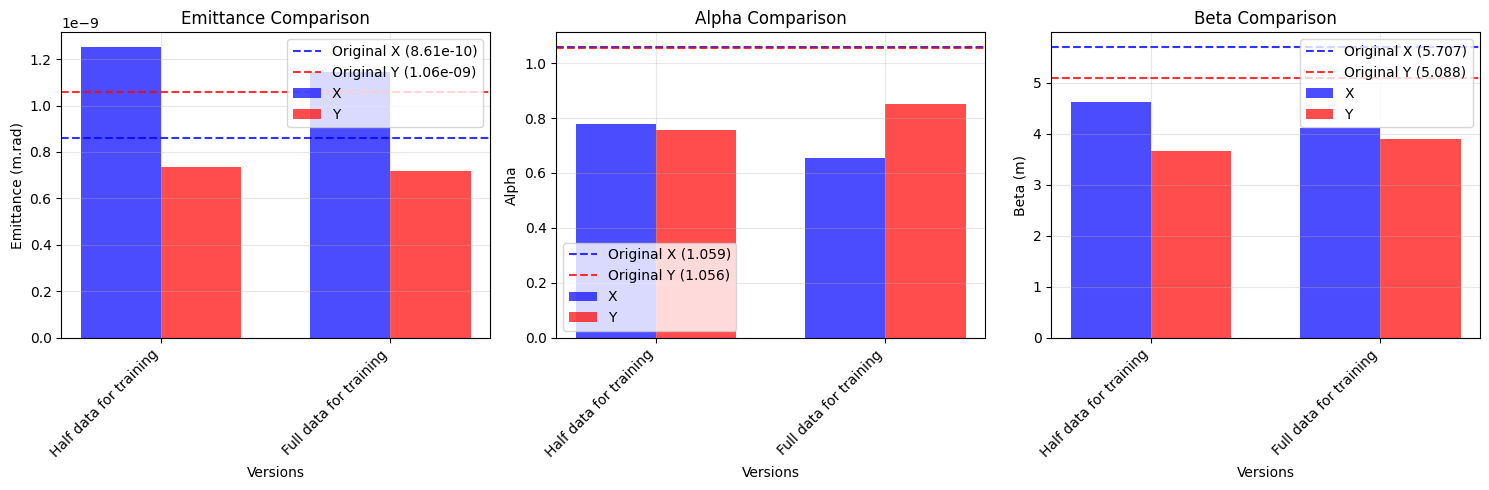

Version  Label           Em_x         Em_y         Alpha_x  Alpha_y  Beta_x   Beta_y  
-------------------------------------------------------------------------------------
62       Half data for training 1.25e-09     7.34e-10     0.778    0.755    4.631    3.668   
63       Full data for training 1.14e-09     7.19e-10     0.656    0.852    4.123    3.894   
-------------------------------------------------------------------------------------
Original Target          8.61e-10     1.06e-09     1.059    1.056    5.707    5.088   


In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

def parse_emittance_file(file_path):
    """Parse emittance_results.txt file and extract parameters"""
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Extract reconstructed parameters
    emittance_x_match = re.search(r'Emittance x: ([\d.e-]+) m\.rad', content)
    alpha_x_match = re.search(r'Alpha x: ([\d.e-]+)', content)
    beta_x_match = re.search(r'Beta x: ([\d.e-]+) m', content)
    
    emittance_y_match = re.search(r'Emittance y: ([\d.e-]+) m\.rad', content)
    alpha_y_match = re.search(r'Alpha y: ([\d.e-]+)', content)
    beta_y_match = re.search(r'Beta y: ([\d.e-]+) m', content)
    
    # Extract original parameters
    orig_emittance_x_match = re.search(r'Original Emittance x: ([\d.e-]+) m\.rad', content)
    orig_alpha_x_match = re.search(r'Original Alpha x: ([\d.e-]+)', content)
    orig_beta_x_match = re.search(r'Original Beta x: ([\d.e-]+) m', content)
    
    orig_emittance_y_match = re.search(r'Original Emittance y: ([\d.e-]+) m\.rad', content)
    orig_alpha_y_match = re.search(r'Original Alpha y: ([\d.e-]+)', content)
    orig_beta_y_match = re.search(r'Original Beta y: ([\d.e-]+) m', content)
    
    reconstructed = {
        'emittance_x': float(emittance_x_match.group(1)) if emittance_x_match else None,
        'alpha_x': float(alpha_x_match.group(1)) if alpha_x_match else None,
        'beta_x': float(beta_x_match.group(1)) if beta_x_match else None,
        'emittance_y': float(emittance_y_match.group(1)) if emittance_y_match else None,
        'alpha_y': float(alpha_y_match.group(1)) if alpha_y_match else None,
        'beta_y': float(beta_y_match.group(1)) if beta_y_match else None,
    }
    
    original = {
        'emittance_x': float(orig_emittance_x_match.group(1)) if orig_emittance_x_match else None,
        'alpha_x': float(orig_alpha_x_match.group(1)) if orig_alpha_x_match else None,
        'beta_x': float(orig_beta_x_match.group(1)) if orig_beta_x_match else None,
        'emittance_y': float(orig_emittance_y_match.group(1)) if orig_emittance_y_match else None,
        'alpha_y': float(orig_alpha_y_match.group(1)) if orig_alpha_y_match else None,
        'beta_y': float(orig_beta_y_match.group(1)) if orig_beta_y_match else None,
    }
    
    return reconstructed, original

def plot_comparison(version_dict):
    """Create comparison plots for emittance, alpha, and beta parameters"""
    
    # Initialize data storage
    versions = []
    labels = []
    emittance_x_vals = []
    emittance_y_vals = []
    alpha_x_vals = []
    alpha_y_vals = []
    beta_x_vals = []
    beta_y_vals = []
    
    original_params = None
    
    # Read data from all versions
    for version, label in version_dict.items():
        file_path = f"./logs/beam_training/version_{version}/final_results/emittance_results.txt"
        
        if os.path.exists(file_path):
            reconstructed, original = parse_emittance_file(file_path)
            
            # Store original parameters (same across versions)
            if original_params is None:
                original_params = original
            
            versions.append(version)
            labels.append(label)
            emittance_x_vals.append(reconstructed['emittance_x'])
            emittance_y_vals.append(reconstructed['emittance_y'])
            alpha_x_vals.append(reconstructed['alpha_x'])
            alpha_y_vals.append(reconstructed['alpha_y'])
            beta_x_vals.append(reconstructed['beta_x'])
            beta_y_vals.append(reconstructed['beta_y'])
        else:
            print(f"Warning: File not found for version {version}")
    
    if not labels:
        print("No valid data found!")
        return
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # X positions for bar plots
    x_pos = np.arange(len(labels))
    width = 0.35
    
    # Plot 1: Emittance comparison (Bar plot)
    bars1 = axes[0].bar(x_pos - width/2, emittance_x_vals, width, label='X', alpha=0.7, color='blue')
    bars2 = axes[0].bar(x_pos + width/2, emittance_y_vals, width, label='Y', alpha=0.7, color='red')
    
    if original_params:
        axes[0].axhline(y=original_params['emittance_x'], color='blue', linestyle='--', 
                       label=f'Original X ({original_params["emittance_x"]:.2e})', alpha=0.8)
        axes[0].axhline(y=original_params['emittance_y'], color='red', linestyle='--', 
                       label=f'Original Y ({original_params["emittance_y"]:.2e})', alpha=0.8)
    
    axes[0].set_xlabel('Versions')
    axes[0].set_ylabel('Emittance (m.rad)')
    axes[0].set_title('Emittance Comparison')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(labels, rotation=45, ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    
    # Plot 2: Alpha comparison (Bar plot)
    bars3 = axes[1].bar(x_pos - width/2, alpha_x_vals, width, label='X', alpha=0.7, color='blue')
    bars4 = axes[1].bar(x_pos + width/2, alpha_y_vals, width, label='Y', alpha=0.7, color='red')
    
    if original_params:
        axes[1].axhline(y=original_params['alpha_x'], color='blue', linestyle='--', 
                       label=f'Original X ({original_params["alpha_x"]:.3f})', alpha=0.8)
        axes[1].axhline(y=original_params['alpha_y'], color='red', linestyle='--', 
                       label=f'Original Y ({original_params["alpha_y"]:.3f})', alpha=0.8)
    
    axes[1].set_xlabel('Versions')
    axes[1].set_ylabel('Alpha')
    axes[1].set_title('Alpha Comparison')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(labels, rotation=45, ha='right')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Beta comparison (Bar plot)
    bars5 = axes[2].bar(x_pos - width/2, beta_x_vals, width, label='X', alpha=0.7, color='blue')
    bars6 = axes[2].bar(x_pos + width/2, beta_y_vals, width, label='Y', alpha=0.7, color='red')
    
    if original_params:
        axes[2].axhline(y=original_params['beta_x'], color='blue', linestyle='--', 
                       label=f'Original X ({original_params["beta_x"]:.3f})', alpha=0.8)
        axes[2].axhline(y=original_params['beta_y'], color='red', linestyle='--', 
                       label=f'Original Y ({original_params["beta_y"]:.3f})', alpha=0.8)
    
    axes[2].set_xlabel('Versions')
    axes[2].set_ylabel('Beta (m)')
    axes[2].set_title('Beta Comparison')
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(labels, rotation=45, ha='right')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary table
    print(f"{'Version':<8} {'Label':<15} {'Em_x':<12} {'Em_y':<12} {'Alpha_x':<8} {'Alpha_y':<8} {'Beta_x':<8} {'Beta_y':<8}")
    print("-" * 85)
    
    for i, version in enumerate(versions):
        print(f"{version:<8} {labels[i]:<15} {emittance_x_vals[i]:<12.2e} {emittance_y_vals[i]:<12.2e} "
              f"{alpha_x_vals[i]:<8.3f} {alpha_y_vals[i]:<8.3f} {beta_x_vals[i]:<8.3f} {beta_y_vals[i]:<8.3f}")
    
    if original_params:
        print("-" * 85)
        print(f"{'Original':<8} {'Target':<15} {original_params['emittance_x']:<12.2e} {original_params['emittance_y']:<12.2e} "
              f"{original_params['alpha_x']:<8.3f} {original_params['alpha_y']:<8.3f} {original_params['beta_x']:<8.3f} {original_params['beta_y']:<8.3f}")

# Example usage with string labels:
version_dict = {
    # 19: "Particles: 40k", 
    # 20: "Particles: 50k",
    # 22: "Training data split: 70-30",
    # 24: "Model dim: 16 (32)",
    # 25: "Feed forward dim: 32 (64)",
    # 26: "Gaussian blur sigma: 3",
    # 27: "Foregrd, bckgrd wts: 10 (20), 1(.5)",
    # 28: "Foregrd, bckgrd wts: 30 (20), 1(.5)",
    # 29: "120x120 image shape",
    # 29: "Learning rate: 1e-2 (1e-3)",
    # 30: "F, b wts: 10, 1, lr: 1e-2",
    # 31: "NNTransform(14,20,14 model),"
    # 34: "150x150 image shape",
    # 38: 'MSE',
    # 39: 'L1',
    # 40: 'Weighted',
    # 41: '10k particles',
    # 42: '20k particles',
    # 40: '40k particles'
    62: 'Half data for training',
    63: 'Full data for training'
}
# version_dict = {k: str(k) for k in range(19,30)}

plot_comparison(version_dict)

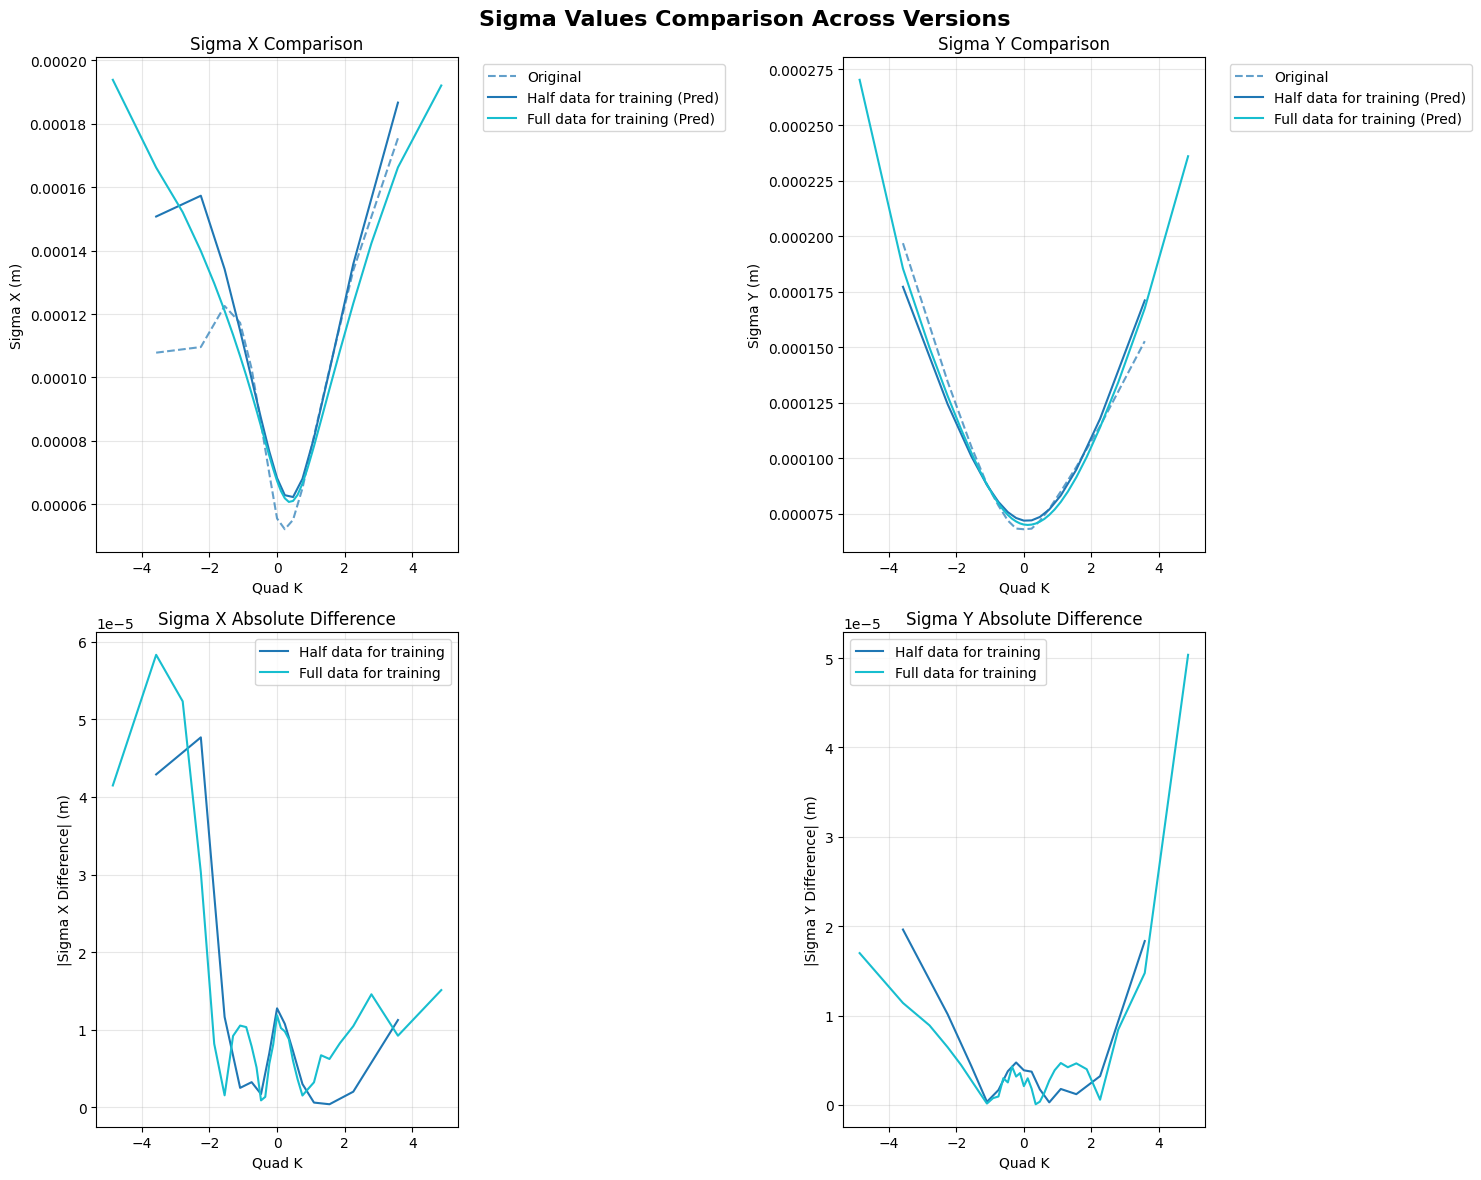

In [2]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import seaborn as sns

def parse_emittance_file(file_path):
    """Parse emittance_results.txt file and extract parameters"""
    with open(file_path, 'r') as f:
        content = f.read()
    
    # Extract reconstructed parameters
    emittance_x_match = re.search(r'Emittance x: ([\d.e-]+) m\.rad', content)
    alpha_x_match = re.search(r'Alpha x: ([\d.e-]+)', content)
    beta_x_match = re.search(r'Beta x: ([\d.e-]+) m', content)
    
    emittance_y_match = re.search(r'Emittance y: ([\d.e-]+) m\.rad', content)
    alpha_y_match = re.search(r'Alpha y: ([\d.e-]+)', content)
    beta_y_match = re.search(r'Beta y: ([\d.e-]+) m', content)
    
    # Extract original parameters
    orig_emittance_x_match = re.search(r'Original Emittance x: ([\d.e-]+) m\.rad', content)
    orig_alpha_x_match = re.search(r'Original Alpha x: ([\d.e-]+)', content)
    orig_beta_x_match = re.search(r'Original Beta x: ([\d.e-]+) m', content)
    
    orig_emittance_y_match = re.search(r'Original Emittance y: ([\d.e-]+) m\.rad', content)
    orig_alpha_y_match = re.search(r'Original Alpha y: ([\d.e-]+)', content)
    orig_beta_y_match = re.search(r'Original Beta y: ([\d.e-]+) m', content)
    
    # Extract error values
    emittance_x_error_match = re.search(r'Emittance x error: ([\d.e-]+)m\.rad', content)
    emittance_y_error_match = re.search(r'Emittance y error: ([\d.e-]+)m\.rad', content)
    alpha_x_error_match = re.search(r'Alpha x error: ([\d.e-]+)', content)
    alpha_y_error_match = re.search(r'Alpha y error: ([\d.e-]+)', content)
    beta_x_error_match = re.search(r'Beta x error: ([\d.e-]+)', content)
    beta_y_error_match = re.search(r'Beta y error: ([\d.e-]+)', content)
    
    reconstructed = {
        'emittance_x': float(emittance_x_match.group(1)) if emittance_x_match else None,
        'alpha_x': float(alpha_x_match.group(1)) if alpha_x_match else None,
        'beta_x': float(beta_x_match.group(1)) if beta_x_match else None,
        'emittance_y': float(emittance_y_match.group(1)) if emittance_y_match else None,
        'alpha_y': float(alpha_y_match.group(1)) if alpha_y_match else None,
        'beta_y': float(beta_y_match.group(1)) if beta_y_match else None,
    }
    
    original = {
        'emittance_x': float(orig_emittance_x_match.group(1)) if orig_emittance_x_match else None,
        'alpha_x': float(orig_alpha_x_match.group(1)) if orig_alpha_x_match else None,
        'beta_x': float(orig_beta_x_match.group(1)) if orig_beta_x_match else None,
        'emittance_y': float(orig_emittance_y_match.group(1)) if orig_emittance_y_match else None,
        'alpha_y': float(orig_alpha_y_match.group(1)) if orig_alpha_y_match else None,
        'beta_y': float(orig_beta_y_match.group(1)) if orig_beta_y_match else None,
    }
    
    errors = {
        'emittance_x': float(emittance_x_error_match.group(1)) if emittance_x_error_match else None,
        'emittance_y': float(emittance_y_error_match.group(1)) if emittance_y_error_match else None,
        'alpha_x': float(alpha_x_error_match.group(1)) if alpha_x_error_match else None,
        'alpha_y': float(alpha_y_error_match.group(1)) if alpha_y_error_match else None,
        'beta_x': float(beta_x_error_match.group(1)) if beta_x_error_match else None,
        'beta_y': float(beta_y_error_match.group(1)) if beta_y_error_match else None,
    }
    
    return reconstructed, original, errors

def load_sigma_data(version_dict):
    """Load sigma comparison data from CSV files"""
    sigma_data = {}
    
    for version, label in version_dict.items():
        csv_path = f"./logs/beam_training/version_{version}/final_results/sigma_values.csv"
        
        if os.path.exists(csv_path):
            try:
                df = pd.read_csv(csv_path)
                sigma_data[version] = {
                    'label': label,
                    'data': df
                }
            except Exception as e:
                print(f"Error loading CSV for version {version}: {e}")
    
    return sigma_data

def plot_comprehensive_comparison(version_dict, save_plots=False, output_dir="./comparison_plots"):
    """Create comprehensive comparison plots for presentations"""
    
    if save_plots:
        os.makedirs(output_dir, exist_ok=True)
    
    # Load emittance data
    versions = []
    labels = []
    reconstructed_data = []
    original_params = None
    error_data = []
    
    for version, label in version_dict.items():
        file_path = f"./logs/beam_training/version_{version}/final_results/emittance_results.txt"
        
        if os.path.exists(file_path):
            reconstructed, original, errors = parse_emittance_file(file_path)
            
            if original_params is None:
                original_params = original
            
            versions.append(version)
            labels.append(label)
            reconstructed_data.append(reconstructed)
            error_data.append(errors)
        else:
            print(f"Warning: File not found for version {version}")
    
    if not labels:
        print("No valid data found!")
        return
    
    
    # SIGMA COMPARISON PLOTS
    sigma_data = load_sigma_data(version_dict)
    
    if sigma_data:
        fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12))
        fig3.suptitle('Sigma Values Comparison Across Versions', fontsize=16, fontweight='bold')
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(sigma_data)))
        
        for i, (version, data) in enumerate(sigma_data.items()):
            df = data['data']
            label = data['label']
            color = colors[i]
            
            # Original vs Predicted Sigma X
            if i == 0:
                axes3[0,0].plot(df['quad_k'], df['orig_sigma_x'], '--', color=color, alpha=0.7, label=f'Original')
            axes3[0,0].plot(df['quad_k'], df['pred_sigma_x'], '-', color=color, label=f'{label} (Pred)')
        
        axes3[0,0].set_xlabel('Quad K')
        axes3[0,0].set_ylabel('Sigma X (m)')
        axes3[0,0].set_title('Sigma X Comparison')
        axes3[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes3[0,0].grid(True, alpha=0.3)
        
        for i, (version, data) in enumerate(sigma_data.items()):
            df = data['data']
            label = data['label']
            color = colors[i]
            
            # Original vs Predicted Sigma Y
            if i==0:
                axes3[0,1].plot(df['quad_k'], df['orig_sigma_y'], '--', color=color, alpha=0.7, label=f'Original')
            axes3[0,1].plot(df['quad_k'], df['pred_sigma_y'], '-', color=color, label=f'{label} (Pred)')
        
        axes3[0,1].set_xlabel('Quad K')
        axes3[0,1].set_ylabel('Sigma Y (m)')
        axes3[0,1].set_title('Sigma Y Comparison')
        axes3[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        axes3[0,1].grid(True, alpha=0.3)
        
        # Sigma difference plots
        for i, (version, data) in enumerate(sigma_data.items()):
            df = data['data']
            label = data['label']
            color = colors[i]
            
            sigma_x_diff = np.abs(df['orig_sigma_x'] - df['pred_sigma_x'])
            sigma_y_diff = np.abs(df['orig_sigma_y'] - df['pred_sigma_y'])
            
            axes3[1,0].plot(df['quad_k'], sigma_x_diff, '-', color=color, label=label)
            axes3[1,1].plot(df['quad_k'], sigma_y_diff, '-', color=color, label=label)
        
        axes3[1,0].set_xlabel('Quad K')
        axes3[1,0].set_ylabel('|Sigma X Difference| (m)')
        axes3[1,0].set_title('Sigma X Absolute Difference')
        axes3[1,0].legend()
        axes3[1,0].grid(True, alpha=0.3)
        
        axes3[1,1].set_xlabel('Quad K')
        axes3[1,1].set_ylabel('|Sigma Y Difference| (m)')
        axes3[1,1].set_title('Sigma Y Absolute Difference')
        axes3[1,1].legend()
        axes3[1,1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        if save_plots:
            plt.savefig(os.path.join(output_dir, 'sigma_comparison.png'), dpi=300, bbox_inches='tight')
        plt.show()
    
    if save_plots:
        print(f"\nAll plots saved to: {output_dir}")

# Example usage
version_dict = {
    # 38: 'MSE',
    # 39: 'L1',
    # 40: 'Weighted',
    # 41: '10k particles',
    # 42: '20k particles',
    # 40: '40k particles'
    62: 'Half data for training', 
    63: 'Full data for training'
}

plot_comprehensive_comparison(version_dict, save_plots=False)